In [2]:
import os
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons
%matplotlib widget

from skimage.io import imread
from skimage.filters import threshold_multiotsu, gaussian
from skimage.morphology import area_closing, area_opening, remove_small_holes, remove_small_objects, closing, disk, opening
from skimage.measure import label, regionprops
from scipy.ndimage import binary_fill_holes
from sklearn.metrics import jaccard_score, multilabel_confusion_matrix


### Define data path

In [3]:
data_path = '/Users/christina.bukas/Documents/AI_projects/datasets/NMO_split_data/Ratio-data'
data_dirs = ['control', 'p1365_SMA_RISD', 'p1365_SMA_untr', 'p1365_SMA_BRAN']

### Get list of all image and mask paths

In [4]:
img_paths = []
mask_paths = []
for data_dir in data_dirs:
    dir_imgs = [os.path.join(data_path, data_dir, file) for file in os.listdir(os.path.join(data_path, data_dir)) if file.endswith('.tif')]
    img_paths.extend(dir_imgs)
    mask_paths.extend([os.path.join(data_path, data_dir, file) for file in os.listdir(os.path.join(data_path, data_dir)) if file.endswith('.tiff')])
    img_paths.sort()
    mask_paths.sort()
    print(data_dir, 'has ', len(dir_imgs), 'images')

control has  7 images
p1365_SMA_RISD has  4 images
p1365_SMA_untr has  4 images
p1365_SMA_BRAN has  4 images


### Read and plot an example

(256, 256) (256, 256)


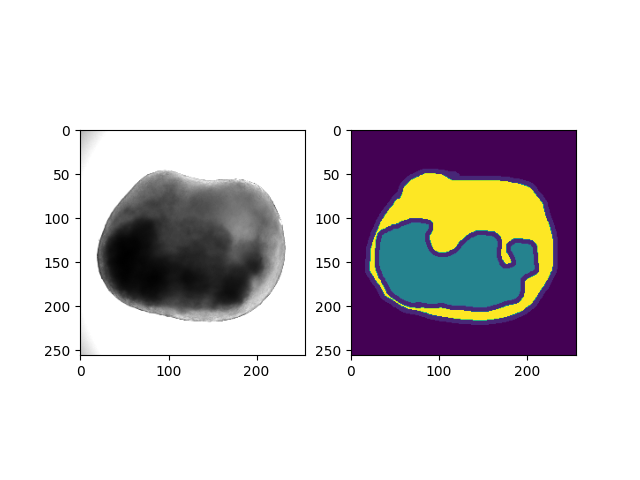

In [4]:
img = imread(img_paths[0], as_gray=True)
mask = imread(mask_paths[0])
print(img.shape, mask.shape)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(mask)
plt.show()

In [10]:
def change_mask_values(mask):
    mask[mask==4] = 1
    mask[mask==9] = 2
    return mask

def dice_score(mask1, mask2, num_classes=3):
    dice_scores = []

    for class_id in range(num_classes):
        class_mask1 = (mask1 == class_id).astype(np.float32)
        class_mask2 = (mask2 == class_id).astype(np.float32)

        intersection = np.sum(class_mask1 * class_mask2)
        union = np.sum(class_mask1) + np.sum(class_mask2)

        dice = (2.0 * intersection) / union if union != 0 else 1.0
        dice_scores.append(dice)

    average_dice = np.mean(dice_scores)
    return average_dice

'''
def fill_holes(mask):

    # Get the unique classes in the segmentation mask
    unique_classes = np.unique(mask)

    # Iterate through each class and fill the holes
    for class_value in unique_classes:
        print(class_value)
        # Create a binary mask for the current class
        class_mask = (mask == class_value).astype(bool)

        # Use binary_fill_holes to fill holes in the binary mask
        filled_mask = binary_fill_holes(class_mask)
        plt.figure()
        plt.imshow(filled_mask)
        plt.show()
        # Update the original mask with the filled holes for the current class
        mask[mask == class_value] = filled_mask[mask == class_value]
    return mask
'''


# Get the two threhsolds for the image using multi-otsu thresholding
def get_mutli_otsu_thresholds(img):
  thresholds = threshold_multiotsu(img, classes=3)
  return thresholds

# Apply the threhsolds from the otsu method and generate a mask
def apply_thresholds(img, thresholds):
  mask = np.zeros(img.shape, dtype=np.uint8)
  mask[img<thresholds[1]] = 9 # neural threshold
  mask[img<thresholds[0]] = 4 # muscle threshold
  return mask

# Compute the ratio of neural and muscle parts on the organoid mask
def compute_nm_ratio(mask):
  n_pix = np.sum(mask==9)
  m_pix = np.sum(mask==4)
  if n_pix==0 and m_pix==0: return 0, 0
  return np.round(n_pix/(n_pix+m_pix), 2), np.round(m_pix/(n_pix+m_pix),2)


def remove_holes_and_objects_old(mask):
    label_mask = label(mask)
    for region in regionprops(label_mask):
        if region.area<500: 
            mask[label_mask==region.label] = 0
    '''
    mask_n = np.zeros_like(mask)
    mask_n[mask==4] = 1
    mask_m = np.zeros_like(mask)
    mask_m[mask==9] = 1
    mask_n = closing(mask_n, disk(3))
    mask_n = binary_fill_holes(mask_n)
    mask_m = closing(mask_m, disk(3))
    mask_m = binary_fill_holes(mask_m)
    mask[mask_n!=0] = 4
    mask[mask_m!=0] = 9
    '''
    return mask

# Remove small areas and holes from both neural and muscle parts
def remove_holes_and_objects(mask, min_size=500): #1000
  label_mask = label(mask)
  for region in regionprops(label_mask):
      if region.area<min_size:
          mask[label_mask==region.label] = 0

  mask_n = np.zeros_like(mask)
  mask_n[mask==4] = 1
  mask_m = np.zeros_like(mask)
  mask_m[mask==9] = 1
  mask_n = binary_fill_holes(mask_n)
  mask_n = opening(mask_n, disk(4))
  mask_m = binary_fill_holes(mask_m)
  mask_m = opening(mask_m, disk(4))
  
  mask[mask_m!=0] = 9
  mask[mask_n!=0] = 4
  return mask

### True mask values
unique values are = 0,1,4,9
backrgound = 0
border = 1
dark part = 4
bright part = 9

control P1339_KOLF_d110_media_O1_ch01.tif


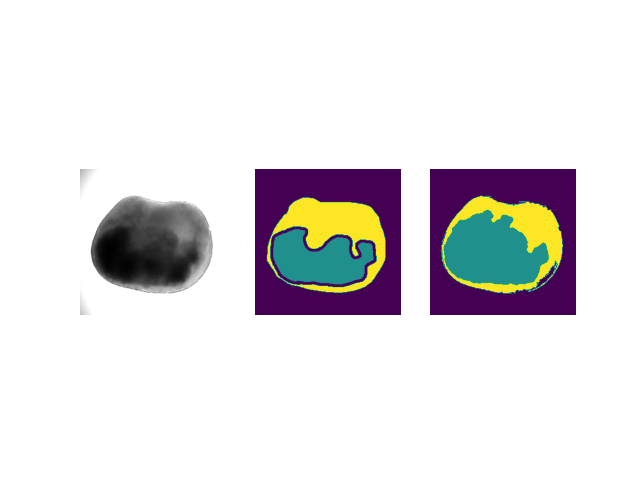

control P1339_KOLF_d114_media_O2_ch01.tif


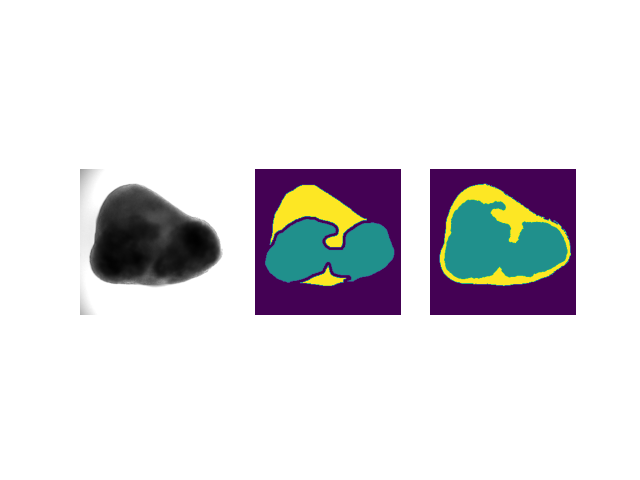

control P1341_KOLF_d75_media_O2_ch01.tif


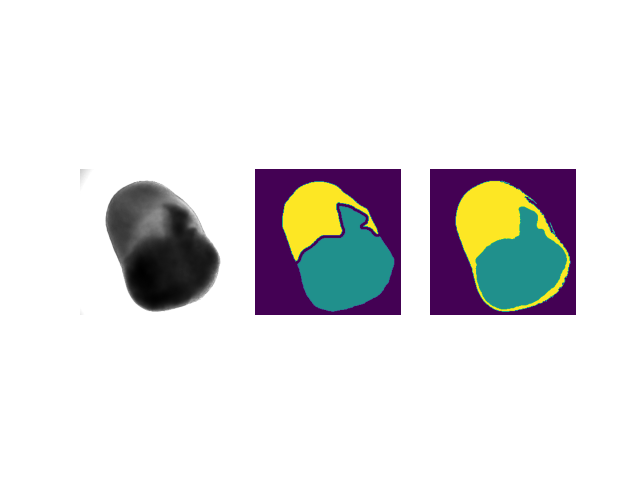

control P1453_a_KOLF_ctrl_d50_O1.tif


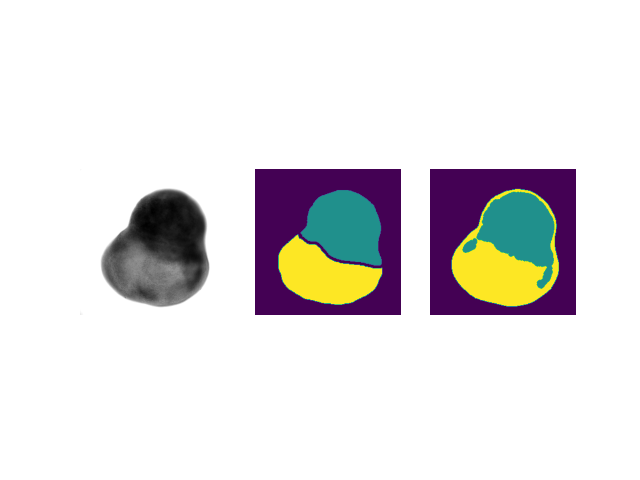

control P1453_a_KOLF_ctrl_d50_O2.tif


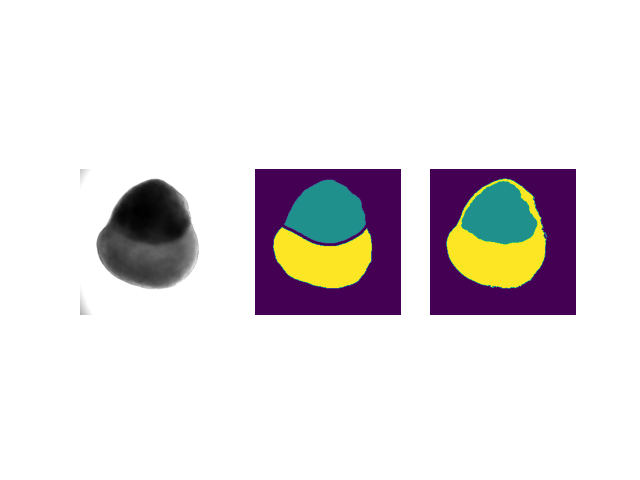

control P1453_a_KOLF_ctrl_d51_O4.tif


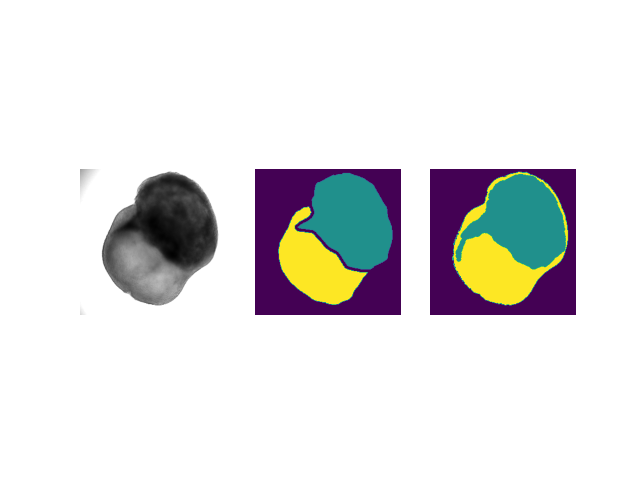

control P1453_a_KOLF_ctrl_d51_O5.tif


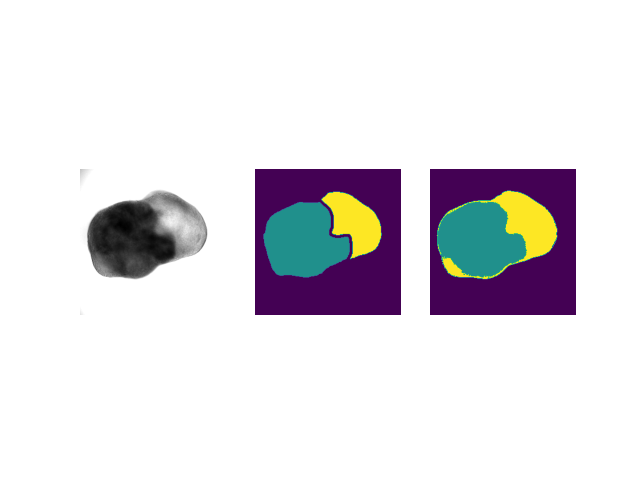

p1365_SMA_BRAN P1365_SMA_BRAN_d58_O1_P1365_SMA_BRAN_d58_O1.lif_ch01.tif


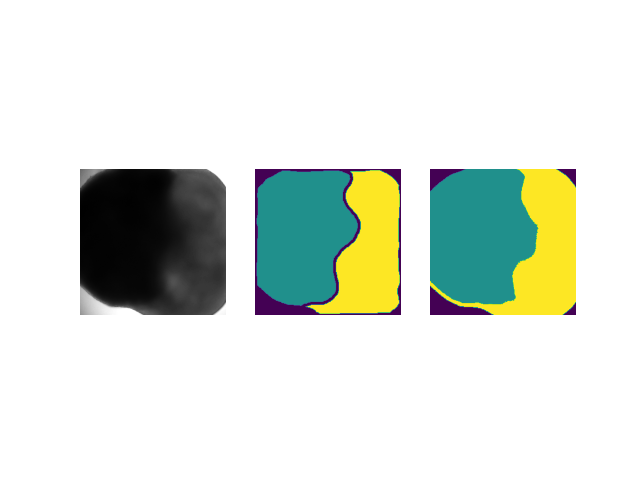

p1365_SMA_BRAN P1365_SMA_BRAN_d58_O2_P1365_SMA_BRAN_d58_O2.lif_ch01.tif


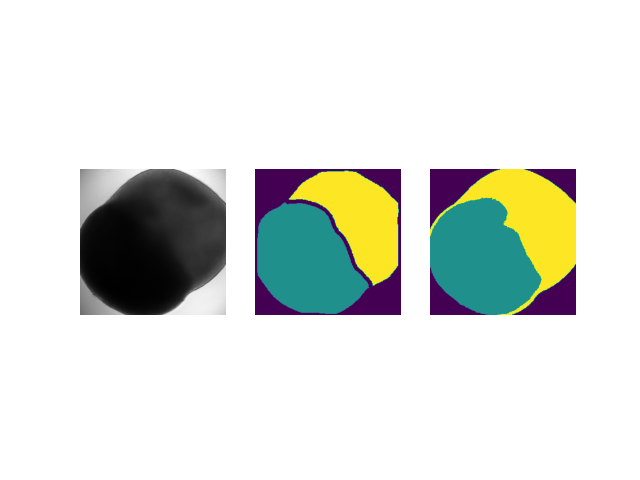

p1365_SMA_BRAN P1365_SMA_BRAN_d60_O3_P1365_SMA_BRAN_d60_O3_ch01.tif


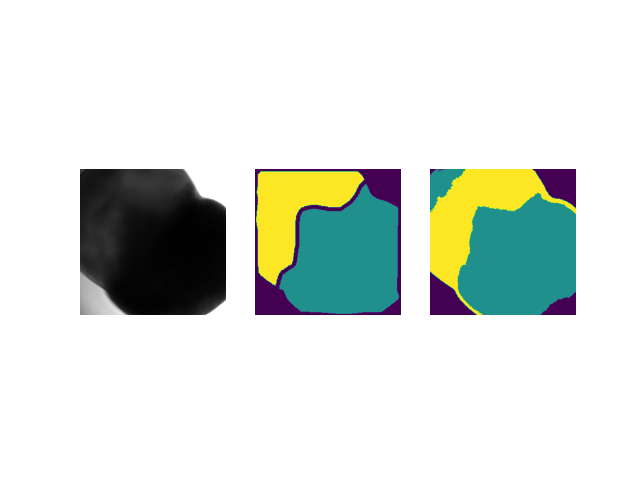

p1365_SMA_BRAN P1365_SMA_BRAN_d60_O4_P1365_SMA_BRAN_d60_O4_ch01.tif


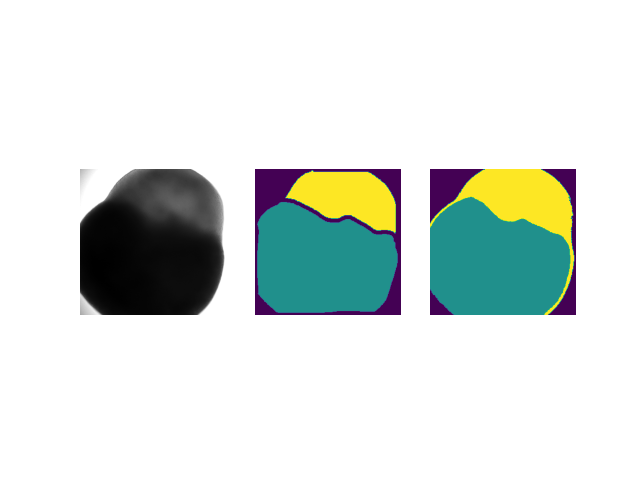

p1365_SMA_RISD P1365_SMA_RISD_d54_O1_P1365_SMA_RISD_d54_O1.lif_ch01.tif


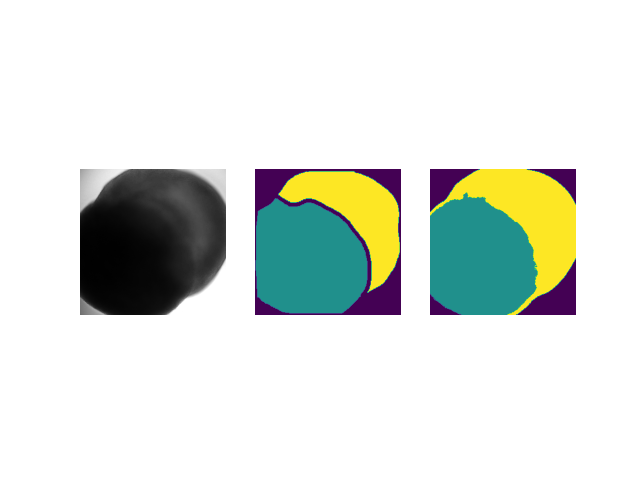

p1365_SMA_RISD P1365_SMA_RISD_d54_O2_P1365_SMA_RISD_d54_O2.lif_ch01.tif


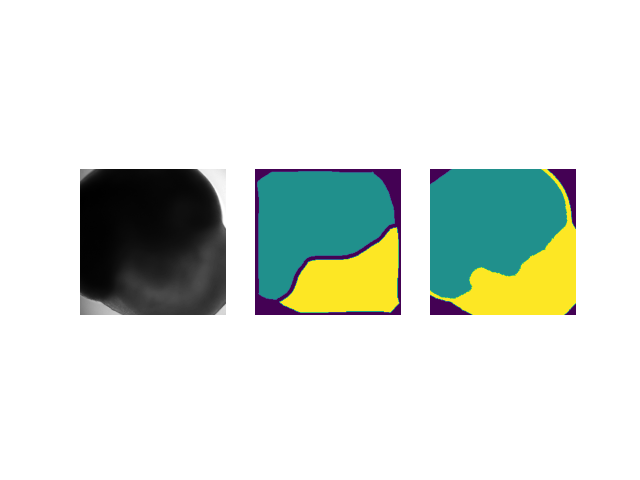

p1365_SMA_RISD P1365_SMA_RISD_d54_O3_P1365_SMA_RISD_d54_O3_ch01.tif


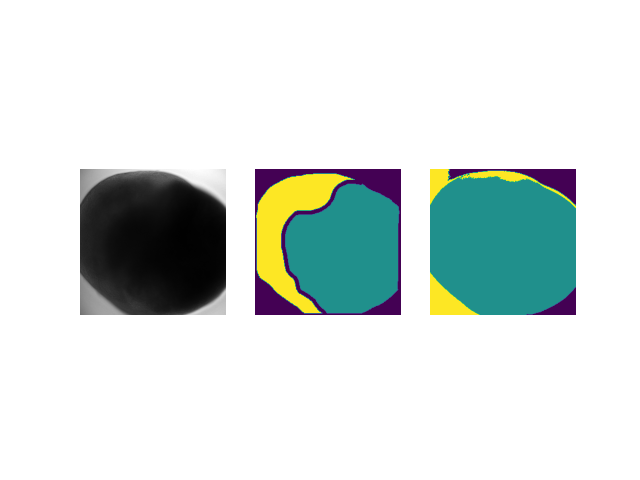

p1365_SMA_RISD P1365_SMA_RISD_d54_O4_P1365_SMA_RISD_d54_O4_ch01.tif


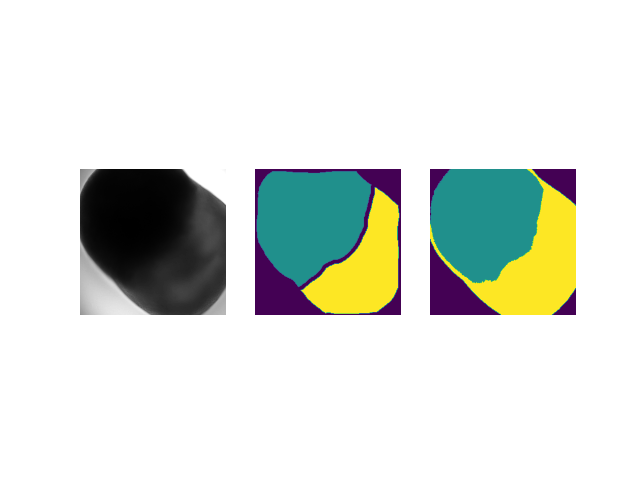

p1365_SMA_untr P1365_SMA_untr_d54_O1_P1365_SMA_untr_d54_O1_ch01.tif


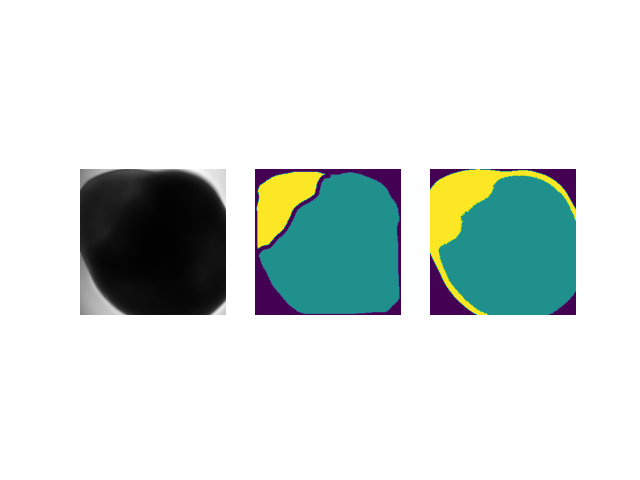

p1365_SMA_untr P1365_SMA_untr_d54_O2_P1365_SMA_untr_d54_O2.lif_ch01.tif


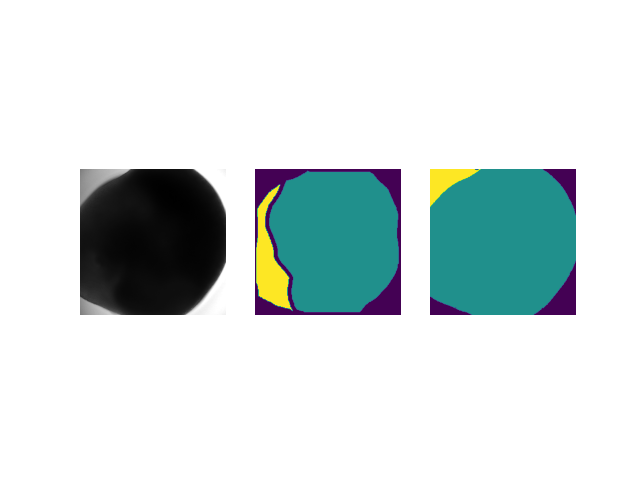

p1365_SMA_untr P1365_SMA_untr_d54_O3_P1365_SMA_untr_d54_O3_ch01.tif


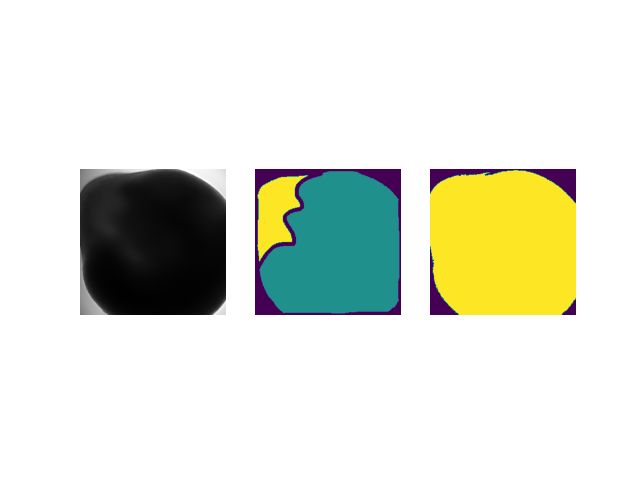

p1365_SMA_untr P1365_SMA_untr_d54_O4_P1365_SMA_untr_d54_O4_ch01.tif


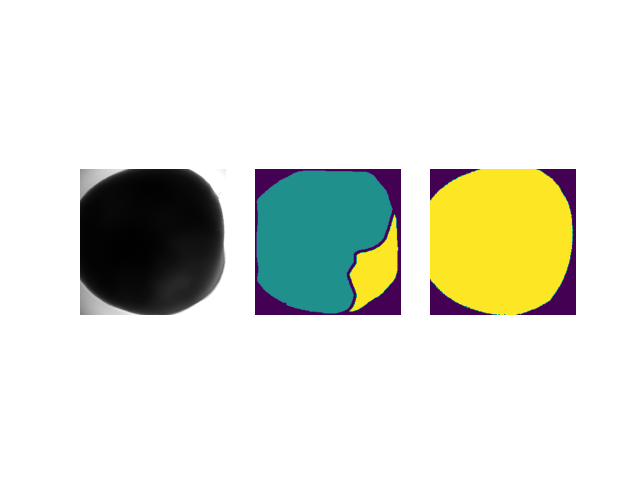

DONE. AVERAGE DICE IS:  0.7973732420479624


In [11]:
avg_dice = 0

for img_path, mask_path in zip(img_paths, mask_paths):
    split = img_path.split('/')
    print(split[-2], split[-1])
    img = imread(img_path, as_gray=True)
    mask_true = imread(mask_path)
    thresholds = get_mutli_otsu_thresholds(img)
    mask_otsu = apply_thresholds(img, thresholds)
    mask_pred = remove_holes_and_objects(mask_otsu, min_size=2000)
    mask_true[mask_true==1] = 0
    dice = dice_score(change_mask_values(mask_true), change_mask_values(mask_pred))
    avg_dice += dice
    #jaccard = jaccard_score(mask_true, mask_otsu, average='samples')
    #cf = multilabel_confusion_matrix(mask_true, mask_otsu)
    
    fig, ax = plt.subplots(1,3)
    ax[0].imshow(img, cmap='gray')
    ax[1].imshow(mask_true)
    ax[2].imshow(mask_pred)
    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')
    plt.show()

    
print('DONE. AVERAGE DICE IS: ', avg_dice/len(img_paths))

## Create an interactive viewer

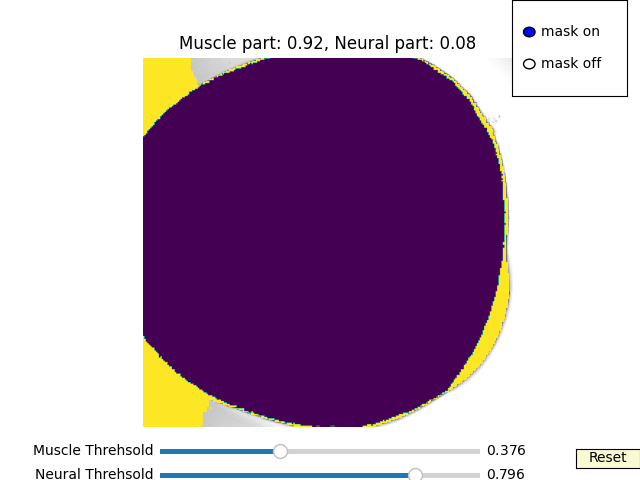

In [ ]:

class Viewer():
  def __init__(self, img):
    self.img = img
    otsu_thresholds = get_mutli_otsu_thresholds(self.img)
    self.mask = apply_thresholds(self.img, otsu_thresholds)
    self.mask = remove_holes_and_objects(self.mask)
    self.n_ratio, self.m_ratio = compute_nm_ratio(self.mask)
    self.thresh0, self.thresh1 = otsu_thresholds
    fig_title = 'Muscle part: '+str(self.m_ratio)+', Neural part: '+str(self.n_ratio)

    # Setup figure properties and add the image to the plot
    self.fig, ax = plt.subplots()
    original_img = ax.imshow(self.img, cmap='gray')
    ax.set_axis_off()
    ax.set_title(fig_title)
    axis_color = 'lightgoldenrodyellow'

    # Define an axes area and draw a slider in it
    thresh0_slider_ax  = self.fig.add_axes([0.25, 0.05, 0.5, 0.02], facecolor=axis_color)
    self.thresh0_slider = Slider(thresh0_slider_ax, 'Muscle Threhsold', 0.0, 1.0, valinit=self.thresh0)
    self.thresh0_slider.on_changed(self.sliders_on_changed)

    # Draw another slider
    threh1_slider_ax = self.fig.add_axes([0.25, 0.0, 0.5, 0.02], facecolor=axis_color)
    self.thresh1_slider = Slider(threh1_slider_ax, 'Neural Threhsold', 0.0, 1.0, valinit=self.thresh1)
    self.thresh1_slider.on_changed(self.sliders_on_changed)

    # Add a button for resetting the parameters
    reset_button_ax = self.fig.add_axes([0.9, 0.025, 0.1, 0.04])
    reset_button = Button(reset_button_ax, 'Reset', color=axis_color, hovercolor='0.975')
    reset_button.on_clicked(self.reset_button_on_clicked)

    # Add a checkbox to switch between views
    radio_ax = self.fig.add_axes([0.8, 0.8, 0.18, 0.2])
    radio_btn = RadioButtons(radio_ax, ('mask on', 'mask off'))
    radio_btn.on_clicked(self.change_view)

    # Overlay the mask on the image
    self.masked_array = np.ma.masked_array(self.mask, ~self.mask.astype(bool))
    self.masked_image = ax.imshow(self.masked_array, cmap='viridis')
    plt.show()

  # Define an action for modifying the image when any slider's value changes
  def sliders_on_changed(self, val):
    self.mask = apply_thresholds(self.img, (self.thresh0_slider.val, self.thresh1_slider.val))
    self.mask = remove_holes_and_objects(self.mask)
    self.n_ratio, self.m_ratio = compute_nm_ratio(self.mask)
    self.masked_image.set_array(np.ma.masked_array(self.mask, ~self.mask.astype(bool)))
    self.fig.canvas.draw_idle()
    ax.set_title('Muscle part: '+str(self.m_ratio)+', Neural part: '+str(self.n_ratio))

  # Update the threshold values once the reset button has been clicked
  def reset_button_on_clicked(self, mouse_event):
    self.thresh0_slider.reset()
    self.thresh1_slider.reset()

  # Switch between simple image view and overlay with mask view
  def change_view(self, label):
    if label=='mask on':
      self.masked_image.set_array(np.ma.masked_array(self.mask, ~self.mask.astype(bool)))
    else:
      self.masked_image.set_array(np.ma.masked_array(self.img, ~np.zeros(self.img.shape).astype(bool)))
    self.fig.canvas.draw_idle()

  def get_ratios(self):
    return self.n_ratio, self.m_ratio

# Read the image selected by the user, compute thresholds, get mask and n-m ratios
viewer = Viewer(img)